In [15]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [16]:
df = pd.read_csv("/content/customer_churn_dataset-training-master.csv.zip")

df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [17]:
df.info()

df.describe()

df.isnull().sum()

df['Churn'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  object 
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  object 
 8   Contract Length    440832 non-null  object 
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), object(3)
memory usage: 40.4+ MB


,count
Churn,
1.0,249999
0.0,190833


In [18]:
df.fillna(method='ffill', inplace=True)

/tmp/ipykernel_739/3970806690.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [19]:
label = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = label.fit_transform(df[col])

In [20]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [22]:
lr = LogisticRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

In [23]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

In [24]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

In [25]:
def evaluate(y_true, pred):

    print("Accuracy :", accuracy_score(y_true,pred))
    print("Precision:", precision_score(y_true,pred))
    print("Recall   :", recall_score(y_true,pred))
    print("F1 Score :", f1_score(y_true,pred))

    cm = confusion_matrix(y_true,pred)

    sns.heatmap(cm,
                annot=True,
                fmt='d',
                cmap='Blues')

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

Accuracy : 0.9780870393684712
Precision: 0.9815942319246945
Recall   : 0.9797497201343355
F1 Score : 0.9806711087100066


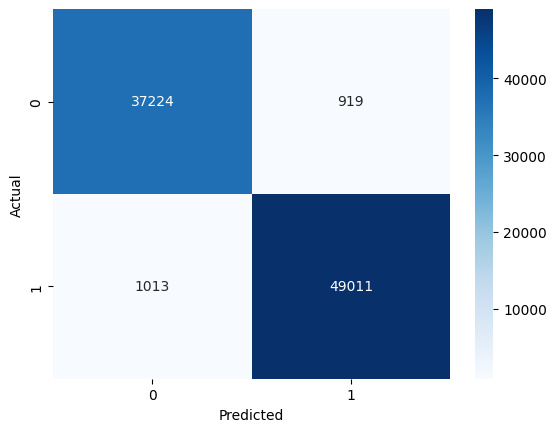

Accuracy : 0.9996710787482845
Precision: 0.9997600911653571
Recall   : 0.9996601631217016
F1 Score : 0.9997101246464021


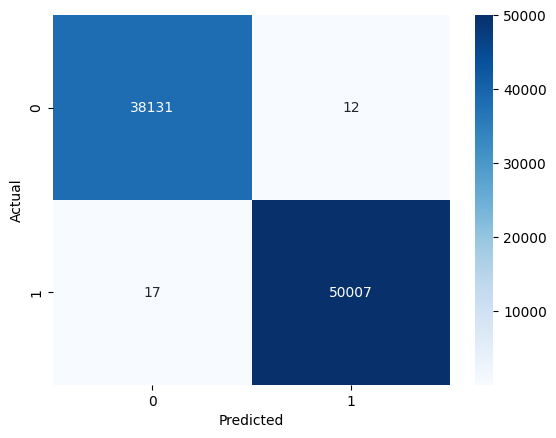

Accuracy : 0.9996143681876439
Precision: 0.9995003996802558
Recall   : 0.9998200863585479
F1 Score : 0.9996602174608251


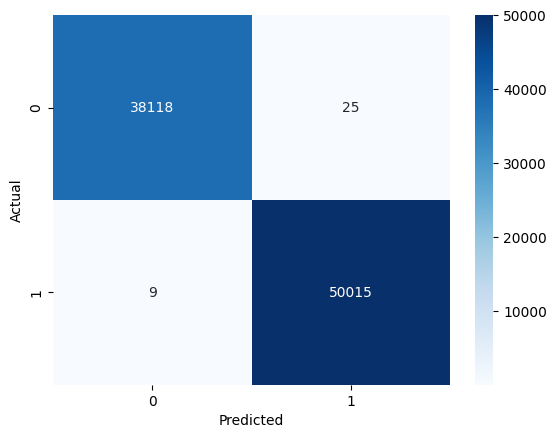

In [26]:
evaluate(y_test,pred_lr)

evaluate(y_test,pred_dt)

evaluate(y_test,pred_rf)

In [27]:
results = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy":[
        accuracy_score(y_test,pred_lr),
        accuracy_score(y_test,pred_dt),
        accuracy_score(y_test,pred_rf)
    ],

    "Precision":[
        precision_score(y_test,pred_lr),
        precision_score(y_test,pred_dt),
        precision_score(y_test,pred_rf)
    ],

    "Recall":[
        recall_score(y_test,pred_lr),
        recall_score(y_test,pred_dt),
        recall_score(y_test,pred_rf)
    ],

    "F1":[
        f1_score(y_test,pred_lr),
        f1_score(y_test,pred_dt),
        f1_score(y_test,pred_rf)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.978087,0.981594,0.97975,0.980671
1,Decision Tree,0.999671,0.999760,0.99966,0.999710
2,Random Forest,0.999614,0.999500,0.99982,0.999660


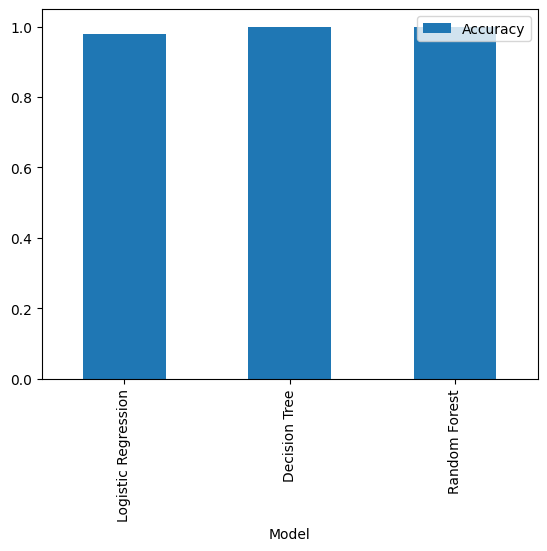

In [28]:
results.plot(
    x='Model',
    y='Accuracy',
    kind='bar'
)

plt.show()